# OpenKind 4E-B.2: candidate ranking and semantic-none detection sweep

**Prepared experiment. No model results have been run in this notebook.**

This tests whether the frozen Qwen3.5-4B-Base candidate-conditioned readout can rank candidate answers and detect when none applies. ContractNLI has two candidate answers and supports ranking metrics. QASPER has one answerable candidate, so it contributes only to answerability and semantic-none detection. The prior 4E-B.1 gate readout showed strong conditional ContractNLI ranking (130/148) but zero semantic-none recall (0/124), with an entailed-majority baseline of 125/148. These are exploratory prior results, not this notebook's result.

The sweep scores each prompt family once, then compares fixed components offline. Fit detector calibration on `calibration_fit`; choose configurations on `policy_development`; report a disjoint diagnostic sample of `calibration_gate` only after selection is frozen. Earlier work already viewed part of the gate, so this readout remains exploratory even with different state IDs. The final split remains closed. No model training, new prompt search, or promotion decision occurs here.

Inputs: pinned Phase 4A corpus and feature bundle, the 4E-B.1 contract for excluding its gate state IDs, and the same fixed model revision. [OpenKind research](https://github.com/whit3rabbit/openpick/blob/main/docs/RESEARCH.md).

## Sweep contract

| Component | Fixed arms |
|---|---|
| ContractNLI candidate ranking | Joint original order; mapped average of original and reversed order; separate yes/no support score for each candidate |
| Semantic-none detection | Joint `Z` probability; negative strongest per-candidate support margin; `No` versus `Yes` on an any-supported question |
| Decision threshold | Calibrated none probability at 0.25, 0.35, 0.50, 0.65, or 0.75 |

Detector calibration uses a one-variable logistic model per source and detector with state-grouped data. Configuration selection maximizes development balanced accuracy across answerable and semantic-none rows; ties use lower full decision NLL, then a fixed lexicographic order. The held-out diagnostic is read once after the selection file is saved. Report conditional ranking accuracy and NLL separately, plus class-balanced accuracy and majority baselines. QASPER never enters a ranking metric.

The fixed sample takes 12 states per source from each split by a SHA-256 key, seed 17. The gate sample excludes all 4E-B.1 gate states. State groups stay intact. Parts are written once per state, with a contract hash and question-ID check for resume. Use a GPU runtime with at least 19 GiB free GPU memory. Reference PyTorch fallbacks for causal convolution and gated DeltaNet may be slow; their warnings do not change the method.

In [10]:
# Install the known parser/runtime version without replacing Colab's Torch build.
import importlib.metadata as im
import subprocess, sys

TORCH_VERSION = im.version('torch')
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--quiet',
    f'torch=={TORCH_VERSION}', 'transformers==5.17.0',
    'numpy>=2,<3', 'pandas>=2,<3', 'pyarrow>=18,<30', 'scikit-learn>=1.5,<2', 'matplotlib>=3.8,<4',
])

import copy, hashlib, json, math, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from google.colab import drive

drive.mount('/content/drive')
assert torch.__version__.startswith('2.11.'), f'Expected Torch 2.11.x, found {torch.__version__}'
assert torch.cuda.is_available(), 'Select a Colab GPU runtime; no CPU fallback for this model.'
torch.set_float32_matmul_precision('highest')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
print('Torch:', torch.__version__, 'Transformers:', im.version('transformers'))
print('GPU:', torch.cuda.get_device_name(0))

Mounted at /content/drive
Torch: 2.11.0+cu128 Transformers: 5.17.0
GPU: NVIDIA L4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch: 2.11.0+cu128 Transformers: 5.17.0
GPU: NVIDIA L4


In [11]:
SEED = 17
MAX_STATES_PER_SOURCE_SPLIT = 12
RUN_LABEL = 'candidate_detection_ranking_sweep_s17_n12_v1'
MODEL_ID = 'Qwen/Qwen3.5-4B-Base'
MODEL_REVISION = '1001bb4d826a52d1f399e183466143f4da7b741b'
PROFILE_ID = 'a047d6802c3f06f085b8'
BUNDLE_SHA256 = '4d9ffdee0aea5c71c666d0feae372cffe79a05934aedee2245012e3a53c23332'
BASE_RUN_ID = '20260921T013558Z'
SOURCES = ('contractnli', 'qasper')
SPLITS = ('calibration_fit', 'policy_development', 'calibration_gate')
MAX_FULL_TOKENS = 4096
PARITY_LOGIT_TOLERANCE = 0.05
PARITY_PROB_TOLERANCE = 0.01
THRESHOLDS = (0.25, 0.35, 0.50, 0.65, 0.75)
RANKERS = ('joint_original', 'joint_order_average', 'separate_support')
DETECTORS = ('joint_z', 'max_support', 'any_supported')

COLAB_ROOT = Path('/content/drive/MyDrive/Colab Notebooks')
BASE_RUN = COLAB_ROOT / 'OpenDecision_Phase4A_StateQuery_results' / BASE_RUN_ID
CORPUS_ROOT = BASE_RUN / 'opendecision-mq-v1'
FEATURE_ROOT = BASE_RUN / 'state_features'
PHASE4D_RUN = (COLAB_ROOT / 'OpenDecision_Phase4D_EvidenceAware_Applicability_results'
               / BASE_RUN_ID / 'b2_evidence_residual_s17')
PRIOR_RUN = (COLAB_ROOT / 'OpenKind_Phase4E_B_Candidate_Option_Logit_results'
             / 'candidate_option_logit_gate16_s17_v2')
RESULT_DIR = (COLAB_ROOT / 'OpenKind_Phase4E_B_Candidate_Detection_Ranking_Sweep_results'
              / RUN_LABEL)
PARTS_DIR = RESULT_DIR / 'state_parts'

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

def json_read(path):
    return json.loads(Path(path).read_text())

def canonical_sha(value):
    encoded = json.dumps(value, sort_keys=True, separators=(',', ':'), ensure_ascii=False,
                         allow_nan=False).encode()
    return hashlib.sha256(encoded).hexdigest()

def write_once(path, value):
    path = Path(path)
    if path.exists():
        raise FileExistsError(path)
    temp = path.with_name(path.name + '.partial')
    temp.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False))
    os.replace(temp, path)

required = [BASE_RUN / 'DECLARED_CONTRACT.json', BASE_RUN / 'MODEL_SELECTION_LOCK.json',
            BASE_RUN / 'NONFINAL_EVALUATION.json', BASE_RUN / 'reference_nonfinal_predictions.parquet',
            FEATURE_ROOT / 'manifest.json', CORPUS_ROOT / 'manifest.json',
            CORPUS_ROOT / 'corpus_lock.json', PHASE4D_RUN / 'NONFINAL_EVALUATION.json',
            PHASE4D_RUN / 'NONFINAL_RESULT_LOCK.json', PRIOR_RUN / 'EXPERIMENT_CONTRACT.json']
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(missing)
if (BASE_RUN / 'FINAL_EVALUATION.json').exists() or (PHASE4D_RUN / 'FINAL_EVALUATION.json').exists():
    raise RuntimeError('A final result is present. Stop and re-audit the evidence boundary.')

declared = json_read(BASE_RUN / 'DECLARED_CONTRACT.json')
model_record = declared['model']
assert (model_record['model_id'], model_record['revision'], model_record['profile_id'],
        model_record['bundle_sha256']) == (MODEL_ID, MODEL_REVISION, PROFILE_ID, BUNDLE_SHA256)
assert declared['declared_before_data_or_predictions'] is True
corpus_manifest = json_read(CORPUS_ROOT / 'manifest.json')
corpus_lock = json_read(CORPUS_ROOT / 'corpus_lock.json')
assert corpus_manifest['run_id'] == BASE_RUN_ID
assert corpus_lock['manifest_sha256'] == canonical_sha(corpus_manifest)
assert corpus_manifest.get('final_labels_or_predictions_opened') is False
for table, expected in corpus_lock['tables'].items():
    if sha256_file(CORPUS_ROOT / f'{table}.parquet') != expected:
        raise RuntimeError(f'Corpus table changed: {table}')
features = json_read(FEATURE_ROOT / 'manifest.json')
assert features['run_id'] == BASE_RUN_ID
assert features['corpus_manifest_sha256'] == corpus_lock['manifest_sha256']
assert features['reference_predictions_exclude_final'] is True
phase4d = json_read(PHASE4D_RUN / 'NONFINAL_EVALUATION.json')
phase4d_lock = json_read(PHASE4D_RUN / 'NONFINAL_RESULT_LOCK.json')
assert phase4d.get('final_opened') is False and phase4d_lock.get('final_opened') is False
assert phase4d_lock['nonfinal_report_sha256'] == sha256_file(PHASE4D_RUN / 'NONFINAL_EVALUATION.json')
prior = json_read(PRIOR_RUN / 'EXPERIMENT_CONTRACT.json')
assert prior['schema'] == 'openkind-candidate-option-logit-audit/v2'
assert prior['run_label'] == 'candidate_option_logit_gate16_s17_v2'
assert prior['split'] == 'calibration_gate' and prior['sources'] == list(SOURCES)
prior_gate_ids = set(prior['selected_state_ids'])

# Read only declared nonfinal partitions. The feature manifest has metadata for
# all states; effective text is dereferenced only for the selected state IDs.
states = pd.read_parquet(CORPUS_ROOT / 'states.parquet',
                         filters=[('split', 'in', list(SPLITS))],
                         columns=['state_id', 'source', 'split'])
states = states.loc[states['source'].isin(SOURCES)].copy()
states = states.loc[~((states['split'] == 'calibration_gate')
                      & states['state_id'].isin(prior_gate_ids))].copy()
states['sample_key'] = states['state_id'].map(
    lambda s: hashlib.sha256(f'{SEED}:{s}'.encode()).hexdigest())
selected_states = (states.sort_values(['split', 'source', 'sample_key', 'state_id'])
                   .groupby(['split', 'source'], sort=True).head(MAX_STATES_PER_SOURCE_SPLIT)
                   .copy())
assert selected_states.groupby(['split', 'source']).size().eq(MAX_STATES_PER_SOURCE_SPLIT).all()
assert len(selected_states) == len(SPLITS) * len(SOURCES) * MAX_STATES_PER_SOURCE_SPLIT
selected_state_ids = set(selected_states['state_id'])
assert not (set(selected_states.loc[selected_states['split'] == 'calibration_gate', 'state_id'])
            & prior_gate_ids)

questions = pd.read_parquet(CORPUS_ROOT / 'questions.parquet',
                            filters=[('state_id', 'in', sorted(selected_state_ids))])
questions = questions.loc[(questions['state_id'].isin(selected_state_ids))
                          & (questions['primitive'] == 'choice')].copy()
assert len(questions) > 0 and questions['question_id'].is_unique
if 'split' in questions:
    assert questions['split'].isin(SPLITS).all()
options = pd.read_parquet(CORPUS_ROOT / 'options.parquet',
                          filters=[('question_id', 'in', sorted(questions['question_id']))])
assert set(options['question_id']) == set(questions['question_id'])
state_feature_index = {row['state_id']: row for row in features['state_files']}
assert selected_state_ids <= set(state_feature_index)
option_groups = {qid: group.sort_values('position').to_dict('records')
                 for qid, group in options.groupby('question_id')}
assert all(1 <= len(v) <= 25 for v in option_groups.values())
questions = questions.merge(selected_states[['state_id', 'source', 'split']], on='state_id',
                            how='left', validate='many_to_one', suffixes=('', '_state'))
for field in ('source', 'split'):
    state_field = field + '_state'
    if state_field in questions:
        assert questions[field].eq(questions[state_field]).all()
        questions = questions.drop(columns=state_field)
assert questions['source'].isin(SOURCES).all() and questions['split'].isin(SPLITS).all()
assert all(len(option_groups[q['question_id']]) >= 2 if q['source'] == 'contractnli'
           else len(option_groups[q['question_id']]) == 1 for q in questions.to_dict('records'))

contract = {
    'schema': 'openkind-candidate-detection-ranking-sweep/v1',
    'run_label': RUN_LABEL, 'seed': SEED, 'sources': list(SOURCES), 'splits': list(SPLITS),
    'max_states_per_source_split': MAX_STATES_PER_SOURCE_SPLIT,
    'selected_state_ids_by_split_source': {
        f'{split}/{source}': selected_states.loc[
            (selected_states['split'] == split) & (selected_states['source'] == source)
        ].sort_values(['sample_key', 'state_id'])['state_id'].tolist()
        for split in SPLITS for source in SOURCES},
    'question_count_by_split_source': {
        f'{split}/{source}': int(len(questions.loc[
            (questions['split'] == split) & (questions['source'] == source)]))
        for split in SPLITS for source in SOURCES},
    'selected_question_ids_sha256': canonical_sha(sorted(questions['question_id'].tolist())),
    'excluded_prior_gate_state_ids_sha256': canonical_sha(sorted(prior_gate_ids)),
    'model': model_record, 'rankers': list(RANKERS), 'detectors': list(DETECTORS),
    'thresholds': list(THRESHOLDS),
    'selection_rule': 'maximize development balanced accuracy; tie lower full NLL, then lexical arm',
    'input_sha256': {str(p.relative_to(COLAB_ROOT)): sha256_file(p) for p in required},
    'parity_logit_tolerance': PARITY_LOGIT_TOLERANCE,
    'parity_probability_tolerance': PARITY_PROB_TOLERANCE,
    'final_opened': False, 'gate_previously_exposed': True,
}
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PARTS_DIR.mkdir(parents=True, exist_ok=True)
contract_path = RESULT_DIR / 'EXPERIMENT_CONTRACT.json'
if contract_path.exists():
    assert json_read(contract_path) == contract, 'Existing run contract differs. Use a new run label.'
else:
    assert not list(PARTS_DIR.iterdir()), 'Parts exist without a contract.'
    write_once(contract_path, contract)
CONTRACT_SHA = sha256_file(contract_path)
print('Frozen', len(selected_states), 'states and', len(questions), 'questions.')
print('Results:', RESULT_DIR)

Frozen 72 states and 741 questions.
Results: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4E_B_Candidate_Detection_Ranking_Sweep_results/candidate_detection_ranking_sweep_s17_n12_v1
Frozen 72 states and 741 questions.
Results: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4E_B_Candidate_Detection_Ranking_Sweep_results/candidate_detection_ranking_sweep_s17_n12_v1


## Pinned model and score functions

The text graph remains FP32. Each state prefix is computed once, then the hybrid cache is deeply copied for each suffix. The first question of each source checks cached versus full-prompt logits for each prompt family. A failed cache or token check stops the sweep.

In [12]:
free_bytes, total_bytes = torch.cuda.mem_get_info()
if free_bytes / 2**30 < 19.0:
    raise RuntimeError(f'Need at least 19 GiB free GPU memory; found {free_bytes / 2**30:.1f} GiB.')

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION,
                                           trust_remote_code=False)
model, load_info = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, trust_remote_code=False,
    dtype=torch.float32, attn_implementation='sdpa', device_map={'': 0},
    output_loading_info=True)
assert type(model).__name__ == 'Qwen3_5ForCausalLM'
assert type(model.model).__name__ == 'Qwen3_5TextModel'
assert sum(p.numel() for p in model.model.parameters()) == 4205751296
assert not any(load_info.get(k) for k in ('missing_keys', 'mismatched_keys', 'error_msgs'))
assert next(model.parameters()).dtype == torch.float32
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
torch.manual_seed(SEED)
print('Model loaded. Free GPU GiB:', round(torch.cuda.mem_get_info()[0] / 2**30, 2))

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Model loaded. Free GPU GiB: 6.13


RuntimeError: Need at least 19 GiB free GPU memory; found 6.1 GiB.

In [ ]:
LETTERS = 'ABCDEFGHIJKLMNOPQRSTUVWXY'  # Z is reserved for semantic none.

def sync():
    torch.cuda.synchronize()

def action_token(letter):
    # The action is one constrained next token, without generation.
    ids = tokenizer.encode(' ' + letter, add_special_tokens=False)
    if len(ids) != 1 or tokenizer.decode(ids) != ' ' + letter:
        raise RuntimeError(f'Answer action is not a single exact token: {letter!r} -> {ids}')
    return ids[0]

action_ids = {letter: action_token(letter) for letter in LETTERS + 'Z'}
assert len(set(action_ids.values())) == len(action_ids)

def prefix_text(state_id):
    effective = state_feature_index[state_id]['effective_state_text']
    return 'Context:\n' + effective + '\n\n'

def suffix_text(question, ordered_options):
    if not 1 <= len(ordered_options) <= len(LETTERS):
        raise RuntimeError('Unsupported candidate count.')
    lines = [
        'Question: ' + str(question['instruction']),
        'Choose the single best option supported by the context. Choose Z if none is supported.',
    ]
    lines.extend(f'{LETTERS[i]}. {option["description"]}'
                 for i, option in enumerate(ordered_options))
    lines.extend(['Z. None of the listed options is supported by the context.', 'Answer:'])
    return '\n'.join(lines)

def encode_text(text):
    return tokenizer.encode(text, add_special_tokens=False)

def model_inputs(ids, prefix_len=0):
    return {
        'input_ids': torch.tensor([ids], dtype=torch.long, device='cuda:0'),
        'attention_mask': torch.ones((1, prefix_len + len(ids)), dtype=torch.long, device='cuda:0'),
        'position_ids': torch.arange(prefix_len, prefix_len + len(ids), device='cuda:0')[None, :],
    }

def cache_tensors(obj, seen=None):
    seen = set() if seen is None else seen
    if id(obj) in seen:
        return
    seen.add(id(obj))
    if isinstance(obj, torch.Tensor):
        yield obj
    elif isinstance(obj, dict):
        for value in obj.values():
            yield from cache_tensors(value, seen)
    elif isinstance(obj, (list, tuple)):
        for value in obj:
            yield from cache_tensors(value, seen)
    elif hasattr(obj, '__dict__'):
        for key, value in vars(obj).items():
            if key != 'prefetch_stream':
                yield from cache_tensors(value, seen)

def cache_signature(cache):
    h = hashlib.sha256()
    for tensor in cache_tensors(cache):
        h.update(str((tuple(tensor.shape), str(tensor.dtype))).encode())
        h.update(tensor.detach().contiguous().view(torch.uint8).cpu().numpy().tobytes())
    return h.hexdigest()

def cache_storages(cache):
    return {t.untyped_storage().data_ptr() for t in cache_tensors(cache) if t.numel()}

def project_last(hidden, letters):
    raw = model.lm_head(hidden[:, -1:, :]).float()[0, 0]
    return np.asarray([float(raw[action_ids[c]].item()) for c in letters], dtype=np.float64)

def prefill(ids):
    with torch.inference_mode():
        out = model.model(**model_inputs(ids), use_cache=True, return_dict=True)
    cache = out.past_key_values
    assert cache is not None and int(cache.get_seq_length()) == len(ids)
    return cache

def cached_logits(root_cache, root_len, suffix_ids, letters, verify_copy=False):
    before = cache_signature(root_cache) if verify_copy else None
    branch = copy.deepcopy(root_cache)
    if verify_copy:
        assert not (cache_storages(root_cache) & cache_storages(branch)), 'Hybrid cache aliases root.'
        assert cache_signature(branch) == before
    with torch.inference_mode():
        out = model.model(**model_inputs(suffix_ids, root_len), past_key_values=branch,
                          use_cache=True, return_dict=True)
        logits = project_last(out.last_hidden_state, letters)
    assert int(out.past_key_values.get_seq_length()) == root_len + len(suffix_ids)
    if verify_copy:
        assert cache_signature(root_cache) == before, 'Root cache mutated by branch.'
    return logits

def full_logits(root_ids, suffix_ids, letters):
    with torch.inference_mode():
        out = model.model(**model_inputs(root_ids + suffix_ids), use_cache=False, return_dict=True)
        return project_last(out.last_hidden_state, letters)

def softmax(logits):
    shifted = np.asarray(logits, dtype=np.float64) - np.max(logits)
    weights = np.exp(shifted)
    return weights / weights.sum()


def score_suffix(root_ids, root_cache, suffix, actions, verify_copy=False):
    suffix_ids = encode_text(suffix)
    if not suffix_ids or len(root_ids) + len(suffix_ids) > MAX_FULL_TOKENS:
        raise RuntimeError(f'Prompt exceeds fixed {MAX_FULL_TOKENS} token bound.')
    sync(); started = time.perf_counter()
    logits = cached_logits(root_cache, len(root_ids), suffix_ids, actions, verify_copy)
    sync(); seconds = time.perf_counter() - started
    return {'logits': {a: float(v) for a, v in zip(actions, logits)},
            'suffix_ids': suffix_ids, 'suffix_tokens': len(suffix_ids),
            'seconds': seconds}

def support_suffix(question, option):
    return ('Question: ' + str(question['instruction']) + '\n'
            + 'Candidate answer: ' + str(option['description']) + '\n'
            + 'Is this candidate answer supported by the context?\n'
            + 'A. Yes\nB. No\nAnswer:')

def any_supported_suffix(question, ordered_options):
    lines = ['Question: ' + str(question['instruction']),
             'Is at least one candidate answer supported by the context?']
    lines.extend(f'Candidate {i + 1}: {o["description"]}'
                 for i, o in enumerate(ordered_options))
    return '\n'.join(lines + ['A. Yes', 'B. No', 'Answer:'])

def check_parity(root_ids, score, actions, source, qid, family):
    expected = full_logits(root_ids, score['suffix_ids'], actions)
    observed = np.array([score['logits'][a] for a in actions])
    logit_diff = float(np.max(np.abs(expected - observed)))
    prob_diff = float(np.max(np.abs(softmax(expected) - softmax(observed))))
    same_action = int(np.argmax(expected)) == int(np.argmax(observed))
    result = {'source': source, 'question_id': qid, 'family': family,
              'max_abs_logit_diff': logit_diff, 'max_abs_probability_diff': prob_diff,
              'same_action': same_action}
    if (logit_diff > PARITY_LOGIT_TOLERANCE or prob_diff > PARITY_PROB_TOLERANCE
            or not same_action):
        raise RuntimeError(f'Cached/full-prompt mismatch: {result}')
    return result

## Score and checkpoint each state

Run this cell after model load. It writes one immutable state part at a time. On restart, run from the top; matching complete parts are checked and skipped. `calibration_gate` logits are computed but are not used in calibration or configuration selection. Close or hide the later gate-readout cell until the selection file exists if manually exploring cells out of order.

In [ ]:
question_by_state = {sid: group.sort_values('question_id').to_dict('records')
                     for sid, group in questions.groupby('state_id')}
ordered_states = (selected_states.assign(split_order=selected_states['split'].map(
    {split: i for i, split in enumerate(SPLITS)}))
    .sort_values(['split_order', 'source', 'sample_key', 'state_id']).to_dict('records'))
first_state_for_source = {source: next(s['state_id'] for s in ordered_states
                                       if s['source'] == source) for source in SOURCES}

for state_number, state in enumerate(ordered_states, 1):
    sid, source, split = state['state_id'], state['source'], state['split']
    expected_qids = [q['question_id'] for q in question_by_state[sid]]
    part_path = PARTS_DIR / (hashlib.sha256(sid.encode()).hexdigest() + '.json')
    if part_path.exists():
        part = json_read(part_path)
        assert part['contract_sha256'] == CONTRACT_SHA and part['state_id'] == sid
        assert part['source'] == source and part['split'] == split
        assert [r['question_id'] for r in part['rows']] == expected_qids
        expected_parity = ({'joint', 'support', 'any_supported'}
                           if sid == first_state_for_source[source] else set())
        assert set(p['family'] for p in part['parity']) == expected_parity
        print(f'{state_number}/{len(ordered_states)} states, resumed', flush=True)
        continue
    root_ids = encode_text(prefix_text(sid))
    sync(); started = time.perf_counter()
    root_cache = prefill(root_ids)
    sync(); root_seconds = time.perf_counter() - started
    part_rows, part_parity = [], []
    verify_state = sid == first_state_for_source[source]
    for qi, question in enumerate(question_by_state[sid]):
        qid = question['question_id']
        ordered_options = option_groups[qid]
        joint_actions = LETTERS[:len(ordered_options)] + 'Z'
        joint = score_suffix(root_ids, root_cache, suffix_text(question, ordered_options),
                             joint_actions, verify_copy=(verify_state and qi == 0))
        reverse = (score_suffix(root_ids, root_cache,
                                suffix_text(question, list(reversed(ordered_options))),
                                joint_actions)
                   if len(ordered_options) > 1 else None)
        support = {}
        for option in ordered_options:
            support[option['option_id']] = score_suffix(
                root_ids, root_cache, support_suffix(question, option), ('A', 'B'),
                verify_copy=(verify_state and qi == 0 and not support))
        any_supported = score_suffix(root_ids, root_cache,
                                     any_supported_suffix(question, ordered_options),
                                     ('A', 'B'), verify_copy=(verify_state and qi == 0))
        if verify_state and qi == 0:
            for family, scored, actions in (
                ('joint', joint, joint_actions),
                ('support', next(iter(support.values())), ('A', 'B')),
                ('any_supported', any_supported, ('A', 'B'))):
                part_parity.append(check_parity(root_ids, scored, actions, source, qid, family))
        target_kind = question['target_kind']
        target_id = None if target_kind == 'semantic_none' else question['target_option_id']
        option_ids = [o['option_id'] for o in ordered_options]
        if target_id is not None:
            assert target_id in option_ids
        part_rows.append({
            'source': source, 'split': split, 'state_id': sid, 'question_id': qid,
            'target_kind': target_kind, 'target_option_id': target_id,
            'option_ids': option_ids, 'joint_logits': joint['logits'],
            'reverse_logits': reverse['logits'] if reverse else None,
            'support_logits': {oid: value['logits'] for oid, value in support.items()},
            'any_supported_logits': any_supported['logits'],
            'root_tokens': len(root_ids), 'root_seconds_amortized': root_seconds / len(expected_qids),
            'suffix_tokens': {'joint': joint['suffix_tokens'],
                              'reverse': reverse['suffix_tokens'] if reverse else None,
                              'support': {oid: v['suffix_tokens'] for oid, v in support.items()},
                              'any_supported': any_supported['suffix_tokens']},
            'suffix_seconds': {'joint': joint['seconds'],
                               'reverse': reverse['seconds'] if reverse else None,
                               'support': {oid: v['seconds'] for oid, v in support.items()},
                               'any_supported': any_supported['seconds']},
        })
    write_once(part_path, {'schema': 'openkind-candidate-sweep-state-part/v1',
                           'contract_sha256': CONTRACT_SHA, 'state_id': sid,
                           'source': source, 'split': split, 'rows': part_rows,
                           'parity': part_parity})
    del root_cache
    torch.cuda.empty_cache()
    print(f'{state_number}/{len(ordered_states)} states, {len(part_rows)} questions saved', flush=True)

parts = []
for state in ordered_states:
    sid = state['state_id']
    part_path = PARTS_DIR / (hashlib.sha256(sid.encode()).hexdigest() + '.json')
    part = json_read(part_path)
    assert part['contract_sha256'] == CONTRACT_SHA
    assert [r['question_id'] for r in part['rows']] == [
        q['question_id'] for q in question_by_state[sid]]
    parts.append(part)
assert sum(len(p['rows']) for p in parts) == len(questions)
print('All', len(parts), 'state parts complete.')

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


1/72 states, 17 questions saved
2/72 states, 17 questions saved
3/72 states, 17 questions saved
4/72 states, 17 questions saved
5/72 states, 17 questions saved
6/72 states, 17 questions saved
7/72 states, 17 questions saved
8/72 states, 17 questions saved
9/72 states, 17 questions saved
10/72 states, 17 questions saved
11/72 states, 17 questions saved
12/72 states, 17 questions saved
13/72 states, 6 questions saved
14/72 states, 5 questions saved
15/72 states, 4 questions saved
16/72 states, 3 questions saved
17/72 states, 2 questions saved
18/72 states, 2 questions saved
19/72 states, 6 questions saved
20/72 states, 3 questions saved
21/72 states, 1 questions saved
22/72 states, 3 questions saved
23/72 states, 3 questions saved
24/72 states, 2 questions saved
25/72 states, 17 questions saved
26/72 states, 17 questions saved
27/72 states, 17 questions saved
28/72 states, 17 questions saved
29/72 states, 17 questions saved
30/72 states, 17 questions saved
31/72 states, 17 questions save

## Calibration and development selection

Only `calibration_fit` labels fit detector probabilities. Only `policy_development` labels select a threshold and component pair. The choice is written once before any gate report. A logistic model is fit separately for each source and detector, with one scalar feature and fixed regularization. A missing class stops the run; it is not patched with a majority guess.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

rows = [r for part in parts for r in part['rows']]
parity_rows = [p for part in parts for p in part['parity']]
assert len(rows) == len(questions) and len({r['question_id'] for r in rows}) == len(rows)

def row_scores(row):
    ids = row['option_ids']
    joint = row['joint_logits']
    raw_joint = softmax([joint[LETTERS[i]] for i in range(len(ids))] + [joint['Z']])
    joint_rank = {oid: float(raw_joint[i] / sum(raw_joint[:-1])) for i, oid in enumerate(ids)}
    if len(ids) > 1:
        rev = row['reverse_logits']
        raw_rev = softmax([rev[LETTERS[i]] for i in range(len(ids))] + [rev['Z']])
        rev_rank = {oid: float(raw_rev[len(ids) - 1 - i] / sum(raw_rev[:-1]))
                    for i, oid in enumerate(ids)}
        avg_rank = {oid: (joint_rank[oid] + rev_rank[oid]) / 2 for oid in ids}
    else:
        avg_rank = joint_rank.copy()
    margins = {oid: row['support_logits'][oid]['A']
               - row['support_logits'][oid]['B'] for oid in ids}
    support_p = softmax([margins[oid] for oid in ids])
    support_rank = {oid: float(p) for oid, p in zip(ids, support_p)}
    return {
        'rank': {'joint_original': joint_rank, 'joint_order_average': avg_rank,
                 'separate_support': support_rank},
        'detector_raw': {
            'joint_z': float(joint['Z'] - np.logaddexp.reduce(
                [joint[LETTERS[i]] for i in range(len(ids))])),
            'max_support': float(-max(margins.values())),
            'any_supported': float(row['any_supported_logits']['B']
                                   - row['any_supported_logits']['A']),
        },
    }

scores = {r['question_id']: row_scores(r) for r in rows}
calibrators = {}
for source in SOURCES:
    fit_rows = [r for r in rows if r['source'] == source and r['split'] == 'calibration_fit']
    labels = np.array([r['target_option_id'] is None for r in fit_rows], dtype=int)
    assert set(labels) == {0, 1}, f'Calibration has only one class: {source}'
    for detector in DETECTORS:
        values = np.array([scores[r['question_id']]['detector_raw'][detector]
                           for r in fit_rows], dtype=float).reshape(-1, 1)
        assert np.isfinite(values).all()
        model_cal = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                                       random_state=SEED)
        model_cal.fit(values, labels)
        calibrators[(source, detector)] = model_cal

def none_probability(row, detector):
    model_cal = calibrators[(row['source'], detector)]
    raw = scores[row['question_id']]['detector_raw'][detector]
    return float(model_cal.predict_proba(np.array([[raw]]))[0, 1])

def evaluate_arm(group, ranker, detector, threshold):
    assert group
    n_none = sum(r['target_option_id'] is None for r in group)
    n_answerable = len(group) - n_none
    correct_none = correct_answerable_action = answerable_not_rejected = correct_all = 0
    conditional_correct = 0
    conditional_nll = full_nll = brier = 0.0
    for r in group:
        p_none = none_probability(r, detector)
        rank = scores[r['question_id']]['rank'][ranker]
        winner = max(rank, key=rank.get)
        target = r['target_option_id']
        predicted_none = p_none >= threshold
        predicted = None if predicted_none else winner
        correct_all += predicted == target
        correct_none += target is None and predicted_none
        answerable_not_rejected += target is not None and not predicted_none
        correct_answerable_action += target is not None and predicted == target
        if target is not None:
            conditional_correct += winner == target
            conditional_nll += -math.log(max(rank[target], 1e-12))
            full_nll += -math.log(max((1 - p_none) * rank[target], 1e-12))
        else:
            full_nll += -math.log(max(p_none, 1e-12))
        brier += (p_none - (target is None)) ** 2 + sum(
            ((1 - p_none) * value - (oid == target)) ** 2 for oid, value in rank.items())
    return {
        'n': len(group), 'none_n': n_none, 'answerable_n': n_answerable,
        'accuracy': correct_all / len(group),
        'balanced_accuracy': ((correct_none / n_none + correct_answerable_action / n_answerable) / 2
                              if n_none and n_answerable else None),
        'detector_balanced_accuracy': ((correct_none / n_none + answerable_not_rejected / n_answerable) / 2
                                       if n_none and n_answerable else None),
        'semantic_none_recall': correct_none / n_none if n_none else None,
        'false_none_rate': 1 - answerable_not_rejected / n_answerable if n_answerable else None,
        'full_nll': full_nll / len(group), 'brier': brier / len(group),
        'conditional_ranking_n': n_answerable if len(group[0]['option_ids']) > 1 else 0,
        'conditional_ranking_accuracy': (conditional_correct / n_answerable
                                         if n_answerable and len(group[0]['option_ids']) > 1 else None),
        'conditional_ranking_nll': (conditional_nll / n_answerable
                                    if n_answerable and len(group[0]['option_ids']) > 1 else None),
    }

development_sweep = {}
selection = {}
for source in SOURCES:
    development = [r for r in rows if r['source'] == source
                   and r['split'] == 'policy_development']
    rankers = RANKERS if source == 'contractnli' else ('joint_original',)
    assert {r['target_option_id'] is None for r in development} == {False, True}
    entries = []
    for ranker in rankers:
        for detector in DETECTORS:
            for threshold in THRESHOLDS:
                metrics = evaluate_arm(development, ranker, detector, threshold)
                entries.append({'ranker': ranker, 'detector': detector,
                                'threshold': threshold, 'metrics': metrics})
    entries.sort(key=lambda e: (-e['metrics']['balanced_accuracy'],
                                e['metrics']['full_nll'], e['ranker'],
                                e['detector'], e['threshold']))
    development_sweep[source] = entries
    selection[source] = {k: entries[0][k] for k in ('ranker', 'detector', 'threshold')}

calibration_payload = {
    f'{source}/{detector}': {'coefficient': float(calibrators[(source, detector)].coef_[0, 0]),
                            'intercept': float(calibrators[(source, detector)].intercept_[0])}
    for source in SOURCES for detector in DETECTORS}
selection_payload = {
    'schema': 'openkind-candidate-sweep-selection/v1',
    'contract_sha256': CONTRACT_SHA,
    'calibration': calibration_payload,
    'development_sweep': development_sweep,
    'selected_by_source': selection,
    'gate_labels_used_for_selection': False,
    'final_opened': False,
}
selection_path = RESULT_DIR / 'DEVELOPMENT_SELECTION.json'
if selection_path.exists():
    assert json_read(selection_path) == selection_payload, 'Existing selection differs.'
else:
    write_once(selection_path, selection_payload)
print('Selected from policy development:')
print(json.dumps(selection, indent=2))

Selected from policy development:
{
  "contractnli": {
    "ranker": "joint_order_average",
    "detector": "joint_z",
    "threshold": 0.35
  },
  "qasper": {
    "ranker": "joint_original",
    "detector": "max_support",
    "threshold": 0.25
  }
}


## Diagnostic readout and plots

The gate sample is disjoint from the 4E-B.1 sample but the gate has been exposed in earlier work. Read these numbers as a bounded diagnostic. The majority baseline predicts the most frequent development class and, for ContractNLI ranking, the most frequent development option label. Report class counts alongside rates.

In [14]:
assert selection_path.is_file()
assert json_read(selection_path) == selection_payload

def auc_metrics(group, detector):
    labels = [int(r['target_option_id'] is None) for r in group]
    probabilities = [none_probability(r, detector) for r in group]
    if len(set(labels)) < 2:
        return {'auroc': None, 'average_precision': None}
    return {'auroc': float(roc_auc_score(labels, probabilities)),
            'average_precision': float(average_precision_score(labels, probabilities))}

def majority_baselines(development, gate):
    none_is_majority = sum(r['target_option_id'] is None for r in development) > len(development) / 2
    majority_position = 0
    if gate[0]['source'] == 'contractnli':
        from collections import Counter
        winner_positions = Counter()
        for r in development:
            if r['target_option_id'] is not None:
                winner_positions[r['option_ids'].index(r['target_option_id'])] += 1
        majority_position = sorted(winner_positions, key=lambda p: (-winner_positions[p], p))[0]
        answerable = [r for r in gate if r['target_option_id'] is not None]
    else:
        answerable = [r for r in gate if r['target_option_id'] is not None]
    none_rows = [r for r in gate if r['target_option_id'] is None]
    predicted = lambda r: None if none_is_majority else r['option_ids'][majority_position]
    result = {
        'full_majority_predict_none': none_is_majority,
        'full_majority_accuracy': sum(predicted(r) == r['target_option_id'] for r in gate) / len(gate),
        'full_majority_balanced_accuracy': (
            sum(predicted(r) is None for r in none_rows) / len(none_rows)
            + sum(predicted(r) == r['target_option_id'] for r in answerable) / len(answerable)) / 2,
        'detector_majority_balanced_accuracy': 0.5,
    }
    if gate[0]['source'] == 'contractnli':
        result['conditional_majority_position'] = int(majority_position)
        result['conditional_majority_n'] = len(answerable)
        result['conditional_majority_accuracy'] = sum(
            r['option_ids'][majority_position] == r['target_option_id'] for r in answerable) / len(answerable)
    return result

gate_report = {}
for source in SOURCES:
    development = [r for r in rows if r['source'] == source
                   and r['split'] == 'policy_development']
    gate = [r for r in rows if r['source'] == source and r['split'] == 'calibration_gate']
    assert {r['target_option_id'] is None for r in gate} == {False, True}, (
        f'Gate sample has only one class: {source}')
    selected = selection[source]
    gate_report[source] = {
        'selected': selected,
        'selected_gate_metrics': evaluate_arm(gate, **selected),
        'selected_development_metrics': evaluate_arm(development, **selected),
        'detector_diagnostics': {d: auc_metrics(gate, d) for d in DETECTORS},
        'majority_baselines': majority_baselines(development, gate),
        'gate_candidate_counts': {str(k): sum(len(r['option_ids']) == k for r in gate)
                                  for k in sorted({len(r['option_ids']) for r in gate})},
    }
    if source == 'contractnli':
        disagreements = 0
        for r in gate:
            s = scores[r['question_id']]['rank']
            disagreements += max(s['joint_original'], key=s['joint_original'].get) != max(
                s['joint_order_average'], key=s['joint_order_average'].get)
        gate_report[source]['order_average_winner_disagreement_n'] = disagreements

report = {
    'schema': 'openkind-candidate-sweep-nonfinal/v1', 'run_label': RUN_LABEL,
    'selection_sha256': sha256_file(selection_path),
    'sample_n': len(rows), 'cache_parity': parity_rows,
    'gate_by_source': gate_report,
    'limits': [
        'Exploratory nonfinal sweep; calibration gate was already exposed in previous work.',
        'Only 12 states per source and split. No untouched confirmation or final split.',
        'QASPER has one candidate, so no ranking metric applies.',
        'Model suffix timing is host-specific; reference fallback kernels may be slower.',
        'No release, service, production throughput, or general Jev parity claim.',
    ], 'final_opened': False,
}
report_path = RESULT_DIR / 'NONFINAL_EVALUATION.json'
if report_path.exists():
    assert json_read(report_path) == report, 'Existing gate report differs.'
else:
    write_once(report_path, report)
print(json.dumps(gate_report, indent=2, allow_nan=False))

{
  "contractnli": {
    "selected": {
      "ranker": "joint_order_average",
      "detector": "joint_z",
      "threshold": 0.35
    },
    "selected_gate_metrics": {
      "n": 204,
      "none_n": 96,
      "answerable_n": 108,
      "accuracy": 0.6176470588235294,
      "balanced_accuracy": 0.625,
      "detector_balanced_accuracy": 0.662037037037037,
      "semantic_none_recall": 0.75,
      "false_none_rate": 0.42592592592592593,
      "full_nll": 0.8318702822498892,
      "brier": 0.48752625341681727,
      "conditional_ranking_n": 108,
      "conditional_ranking_accuracy": 0.8703703703703703,
      "conditional_ranking_nll": 0.41683588921960313
    },
    "selected_development_metrics": {
      "n": 204,
      "none_n": 83,
      "answerable_n": 121,
      "accuracy": 0.6225490196078431,
      "balanced_accuracy": 0.6383052872647615,
      "detector_balanced_accuracy": 0.671363138504431,
      "semantic_none_recall": 0.7228915662650602,
      "false_none_rate": 0.3801652892561

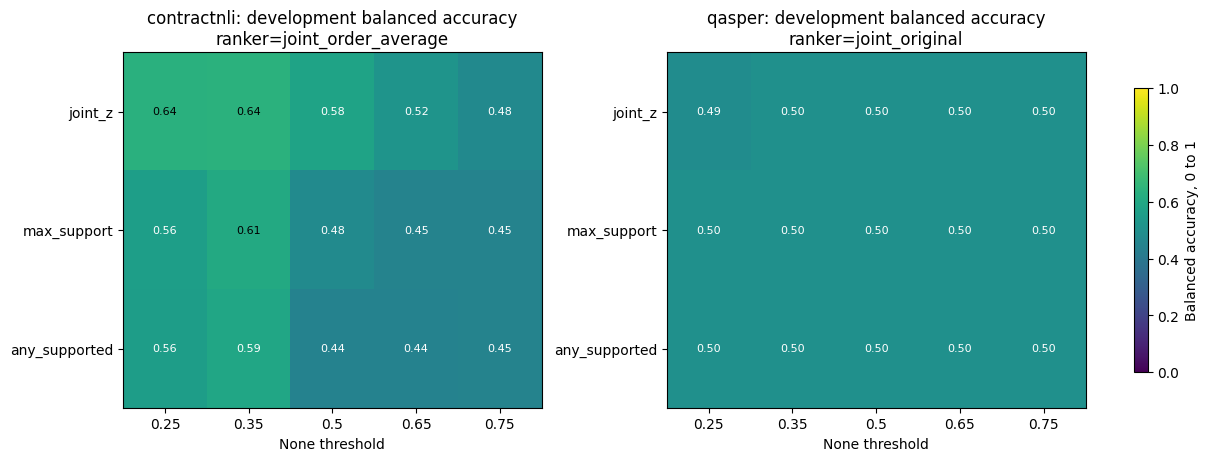

contractnli: selected gate balanced accuracy 0.625 (n=204; none=96; answerable=108); majority 0.389
  Conditional ranking 0.870 (n=108); majority 0.778
qasper: selected gate balanced accuracy 0.500 (n=46; none=5; answerable=41); majority 0.500


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, source in zip(axes, SOURCES):
    selected_ranker = selection[source]['ranker']
    matrix = np.array([[max(e['metrics']['balanced_accuracy'] for e in development_sweep[source]
                             if e['ranker'] == selected_ranker and e['detector'] == detector
                             and e['threshold'] == threshold)
                        for threshold in THRESHOLDS] for detector in DETECTORS])
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(THRESHOLDS)), labels=[str(t) for t in THRESHOLDS])
    ax.set_yticks(range(len(DETECTORS)), labels=DETECTORS)
    ax.set_xlabel('None threshold')
    ax.set_title(f'{source}: development balanced accuracy\nranker={selected_ranker}')
    for y in range(len(DETECTORS)):
        for x in range(len(THRESHOLDS)):
            ax.text(x, y, f'{matrix[y, x]:.2f}', ha='center', va='center',
                    color='white' if matrix[y, x] < 0.6 else 'black', fontsize=8)
fig.colorbar(image, ax=axes, label='Balanced accuracy, 0 to 1', shrink=0.8)
plt.show()

for source in SOURCES:
    record = gate_report[source]
    metrics = record['selected_gate_metrics']
    baseline = record['majority_baselines']
    print(f'{source}: selected gate balanced accuracy {metrics["balanced_accuracy"]:.3f} '
          f'(n={metrics["n"]}; none={metrics["none_n"]}; answerable={metrics["answerable_n"]}); '
          f'majority {baseline["full_majority_balanced_accuracy"]:.3f}')
    if source == 'contractnli':
        print(f'  Conditional ranking {metrics["conditional_ranking_accuracy"]:.3f} '
              f'(n={metrics["conditional_ranking_n"]}); '
              f'majority {baseline["conditional_majority_accuracy"]:.3f}')

## Save immutable readout

This cell creates the row table and result lock after the report. Re-running with the same contract verifies matching hashes and does not overwrite completed outputs. The output contains nonfinal data only.

In [16]:
rows_path = RESULT_DIR / 'NONFINAL_ROWS.parquet'
lock_path = RESULT_DIR / 'NONFINAL_RESULT_LOCK.json'
frame = pd.DataFrame([{
    **{k: v for k, v in r.items() if k not in ('option_ids', 'joint_logits',
       'reverse_logits', 'support_logits', 'any_supported_logits', 'suffix_tokens', 'suffix_seconds')},
    'option_ids_json': json.dumps(r['option_ids']),
    'joint_logits_json': json.dumps(r['joint_logits'], sort_keys=True),
    'reverse_logits_json': json.dumps(r['reverse_logits'], sort_keys=True),
    'support_logits_json': json.dumps(r['support_logits'], sort_keys=True),
    'any_supported_logits_json': json.dumps(r['any_supported_logits'], sort_keys=True),
    'suffix_tokens_json': json.dumps(r['suffix_tokens'], sort_keys=True),
    'suffix_seconds_json': json.dumps(r['suffix_seconds'], sort_keys=True),
} for r in rows]).sort_values(['split', 'source', 'state_id', 'question_id']).reset_index(drop=True)
if rows_path.exists():
    existing = pd.read_parquet(rows_path)
    assert existing.equals(frame), 'Existing rows differ.'
else:
    temp = rows_path.with_name(rows_path.name + '.partial')
    frame.to_parquet(temp, index=False)
    os.replace(temp, rows_path)
lock = {
    'schema': 'openkind-candidate-sweep-result-lock/v1', 'run_label': RUN_LABEL,
    'contract_sha256': CONTRACT_SHA,
    'selection_sha256': sha256_file(selection_path),
    'rows_sha256': sha256_file(rows_path),
    'report_sha256': sha256_file(report_path),
    'state_parts': {p.name: sha256_file(p) for p in sorted(PARTS_DIR.glob('*.json'))},
    'row_count': len(rows), 'final_opened': False,
}
if lock_path.exists():
    assert json_read(lock_path) == lock, 'Existing result lock differs.'
else:
    write_once(lock_path, lock)
print('Saved:', RESULT_DIR)

Saved: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4E_B_Candidate_Detection_Ranking_Sweep_results/candidate_detection_ranking_sweep_s17_n12_v1


## Reading the result

Compare selected gate balanced accuracy with the full-action majority baseline and inspect semantic-none recall, false-none rate, and conditional ranking. ContractNLI conditional ranking must also beat its development-label majority on the matched gate rows. If none recall rises only through a high false-none rate, the detector has not solved applicability. Inspect the complete sweep table in `DEVELOPMENT_SELECTION.json`, the selected gate metrics in `NONFINAL_EVALUATION.json`, and the per-question scores in `NONFINAL_ROWS.parquet`. The split and prior-gate exclusions are recorded in `EXPERIMENT_CONTRACT.json`. This notebook does not open the final panel or warrant promotion.